In [1]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
from skimage.transform import radon, iradon
from skimage.restoration import denoise_tv_chambolle
import astra # https://astra-toolbox.com/docs/index.html
astra.test();

ASTRA Toolbox v2.4.1
Getting GPU info... GPU #0: Quadro T1000 with Max-Q Design, with 4095MB, CUDA compute capability 7.5
Testing basic CPU 2D functionality... Ok
Testing basic CUDA 2D functionality... Ok
Testing basic CUDA 3D functionality... Ok


# Data
Using XCAT dataset 'sampling_300ms_compressed.mat'.
This data originally has dimensions 400x400x50x100. I.e. 100 samples of 50 slices, each 400x400.
Opening the dataset using h5py reverses the order, so it is now 100x50x400x400.

In [2]:
file = h5py.File('data/sampling_300ms_compressed.mat', 'r');
data = file['data2'];

N = 400; # NxN images
SLICES = 50; # slices per sample
SAMPLES = 100; 

print(f"Number of samples: {len(data)}");
print(f"Number of slices: {len(data[0,:,:,:])}");
print(f"Dimensions: {len(data[0,0,:,:])}x{len(data[0,0,0,:])}");

# TODO may extract one breath cycle here

Number of samples: 100
Number of slices: 50
Dimensions: 400x400


In [25]:
# Remember to close the file when done
file.close();

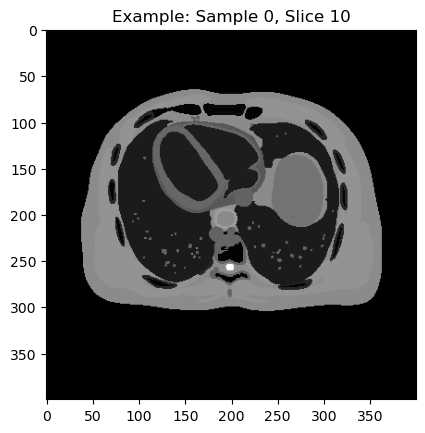

In [23]:
# Example to test loaded, extracting one slice at sample 0, slice 10
ex_image = data[14, 10, :, :];
ex_image = np.rot90(ex_image, k=-1, axes=(0,1)); # rotate 90 deg clockwise
plot = plt.figure();
plot = plt.imshow(ex_image, cmap='grey');
plt.title("Example: Sample 0, Slice 10");
plt.savefig('fig/example_slice.png');
plt.show(plot)

# Breathing Cycle Animation

In [ ]:
# Animation to demonstrate breathing cycle in XCAT
import matplotlib.animation as animation
from IPython.display import Image, display

start = 0;
end = 14 + 1;
#end = 88 + 1;

images = data[start:end-1, 10, :, :];
images = np.rot90(images, k=-1, axes=(1,2));

im = plt.imshow(images[0], cmap='grey');

def updateFig(f):
    im.set_array(images[f]);
    return [im];

fig = plt.gcf();
ani = animation.FuncAnimation(fig, updateFig, frames=range(end-1), interval=300, blit=False);
ani.save('fig/animation.gif', writer='pillow', fps=3.33);

plt.close(fig);
display(Image(filename='fig/animation.gif'));

# Radial MRI
(explain radial MRI, golden angle, spokes, etc. here)

Parameters:
- sample_rate: sample rate of dataset (300ms)
- frames: the number of samples in one breath cycle
- tr: repetition time, the time to acquire one spoke [s]
- breaths: the number of breaths in the simulation
- cycle_time: the time [s] of one breath
- spokes: the number of spokes collected

Given the number of frames, breaths, cycle time, and tr, calculate the corresponding number of spokes that will be taken during this time.

In [25]:
# Constants
GOLDEN_ANGLE = 111.246;
sample_rate = 0.3; # 300 ms
frames = 15; # frames to simulate
slice_idx = 10; 

# TODO look at graphs in MATLAB to determine one breathing cycle start/end
# this is currently taking all 100 frames of around 2.5 breaths as one. 
# change to extract frames from one breath and update frames (changing fs as well to be more realistic)

tr = 0.04; # time to acquire 1 spoke [s] - change back to 0.004 s!
breaths = 1;
cycle_time = frames * sample_rate;
spokes = int(np.floor((breaths * cycle_time) / tr));

print(f"Running simulation with {frames} frames at fs={sample_rate}, TR={tr}, {breaths} breaths at {cycle_time}s each: {spokes} spokes.");

angles = np.arange(spokes) * GOLDEN_ANGLE;
angles = np.mod(angles, 180.0);
assert(len(angles) == spokes);

Running simulation with 15 frames at fs=0.3, TR=0.04, 1 breaths at 4.5s each: 112 spokes.


# Forward Process
Project all spokes using radial sampling
Index: the frame of the phantom to project

In [ ]:
# Forward process
GOLDEN_ANGLE = 111.246;

# change this to only take the slice to not load as much into memory
data_gt = data[0:frames, :, :, :]; 
data_gt = np.rot90(data_gt, k=-1, axes=(2,3));
data_gt = data_gt.astype(float);

angles_deg = np.arange(spokes) * GOLDEN_ANGLE;
angles_deg = np.mod(angles_deg, 180.0);
angles_rad = np.deg2rad(angles_deg); # ASTRA requires radians

sinogram = np.zeros((566, spokes)); # initialize overall sinogram

# ASTRA geometry
vol_geom = astra.create_vol_geom(N, N);
detector_width = int(np.ceil(np.sqrt(N**2 + N**2))); # imitate circle=False (should be 566)

for i in range(spokes):
    t = i * tr; # absolute time of this projection
    idx = int(np.floor(t/sample_rate));
    print(f"idx={idx}");
    
    p = data_gt[idx, slice_idx, :, :]; # NxN phantom at slice, idx
    p = p.astype(float);

    proj_geom = astra.create_proj_geom('parallel', 1.0, detector_width, [angles_rad[i]]); 
    proj_id = astra.create_projector('cuda', proj_geom, vol_geom);
    
    sino_id, sino = astra.create_sino(p, proj_id); # memory obj (sino_id)
    
    sinogram[:, i] = sino[0, :]; # save this column, reverse ASTRA order

    # clean up memory
    astra.projector.delete(proj_id)
    astra.data2d.delete(sino_id);

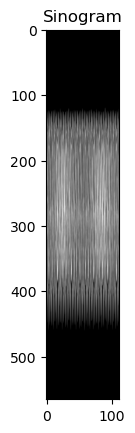

In [67]:
plot = plt.figure();
plot = plt.imshow(sinogram, cmap='grey');
plt.title("Sinogram");
plt.savefig('fig/sinogram.png');
plt.show(plot)

In [68]:
# backward process

# create new proj geometry with all angles
all_proj_geom = astra.create_proj_geom('parallel', 1.0, detector_width, angles_rad); 

# create pointer to sinogram
sino_overall_id = astra.data2d.create('-sino', all_proj_geom, sinogram.T);

# create C++ obj to hold reconstruction
rec_id = astra.data2d.create('-vol', vol_geom); 

# configure FBP
cfg = astra.astra_dict('FBP_CUDA');
cfg['ReconstructionDataId'] = rec_id;
cfg['ProjectionDataId'] = sino_overall_id;
cfg['FilterType'] = 'Ram-Lak';

alg_id = astra.algorithm.create(cfg);
astra.algorithm.run(alg_id);

reconstructed_fbp = astra.data2d.get(rec_id);

# cleanup
astra.algorithm.delete(alg_id);
astra.data2d.delete(rec_id);
astra.data2d.delete(sino_overall_id);

# clip negative values
reconstructed_fbp = np.clip(reconstructed_fbp, 0, None);
#reconstructed_fbp = np.rot90(reconstructed_fbp, k=-1, axes=(0,1));

print(f"Recon Min: {np.min(reconstructed_fbp)}, Max: {np.max(reconstructed_fbp)}")

Recon Min: 0.0, Max: 155.79776000976562


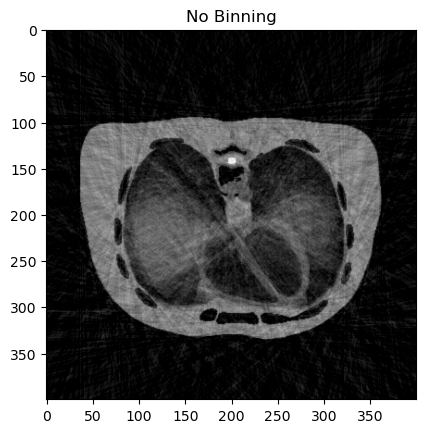

In [69]:
plot = plt.figure();
plot = plt.imshow(reconstructed_fbp, cmap='grey');
plt.title("No Binning");
plt.savefig('fig/example_astra_all.png');
plt.show(plot)

# Example (ASTRA)

In [3]:
# Example
GOLDEN_ANGLE = 111.246;
ex_gt = data[0, 10, :, :];
ex_gt = np.rot90(ex_gt, k=-1, axes=(0,1));
ex_gt = ex_gt.astype(float)

angles_deg = np.arange(100) * GOLDEN_ANGLE;
angles_deg = np.mod(angles_deg, 180.0);
angles_rad = np.deg2rad(angles_deg); # ASTRA requires radians

# ASTRA geometry
vol_geom = astra.create_vol_geom(N, N);
detector_width = int(np.ceil(np.sqrt(N**2 + N**2))); # imitate circle=False (should be 566)
proj_geom = astra.create_proj_geom('parallel', 1.0, detector_width, angles_rad); # parallel beam
proj_id = astra.create_projector('cuda', proj_geom, vol_geom);

# forward process
sino_id, ex_sinogram = astra.create_sino(ex_gt, proj_id); # memory obj (sino_id)

# backward process
rec_id = astra.data2d.create('-vol', vol_geom); # create C++ obj to hold reconstruction

# configure FBP
cfg = astra.astra_dict('FBP_CUDA');
cfg['ReconstructionDataId'] = rec_id;
cfg['ProjectionDataId'] = sino_id;
cfg['FilterType'] = 'Ram-Lak';

alg_id = astra.algorithm.create(cfg);
astra.algorithm.run(alg_id);

ex_reconstructed = astra.data2d.get(rec_id);

# cleanup
astra.algorithm.delete(alg_id);
astra.data2d.delete(rec_id);
astra.data2d.delete(sino_id);

# clip negative values
ex_reconstructed = np.clip(ex_reconstructed, 0, None);

# normalize
ex_gt_norm = ex_gt / np.max(ex_gt);
ex_reconstructed_norm = ex_reconstructed / np.max(ex_reconstructed);

# calculate difference
diff = np.abs(ex_gt_norm - ex_reconstructed_norm);

print(f"Ground Truth Min: {np.min(ex_gt)}, Max: {np.max(ex_gt)}")
print(f"Recon Min: {np.min(ex_reconstructed)}, Max: {np.max(ex_reconstructed)}")
print(f"Diff Min: {np.min(diff)}, Max: {np.max(diff)}")

Ground Truth Min: 0.0, Max: 139.0
Recon Min: 0.0, Max: 145.6977996826172
Diff Min: 0.0, Max: 0.3000432593788175


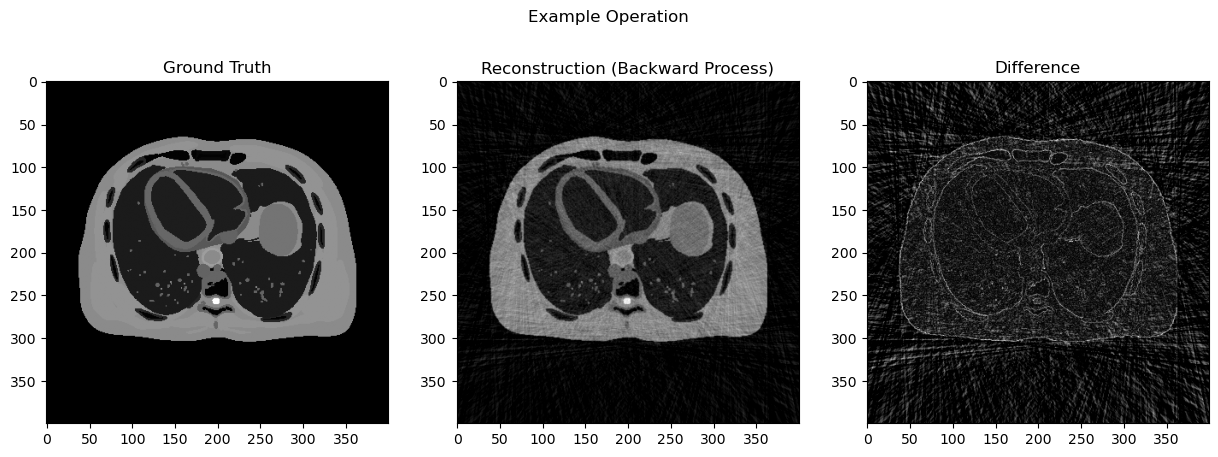

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5));
fig.suptitle('Example Operation');

ax1.set_title('Ground Truth');
im1 = ax1.imshow(ex_gt, cmap='grey');
ax2.set_title('Reconstruction (Backward Process)');
im2 = ax2.imshow(ex_reconstructed, cmap='grey');
ax3.set_title('Difference');
im3 = ax3.imshow(diff, cmap='grey');

plt.savefig('fig/Example.png');
plt.show();

# TV Iterative Reconstruction
$ \displaystyle \min_{u} \frac{1}{2} ||Au - f||_2^2 + \lambda TV(u) $

Where $A$ is the forward radon process, $A^T$ is the backward radon process, $u$ is the initial guess, and $f$ is the raw sinogram data. 
$ \nabla = A^T(Au-f)$

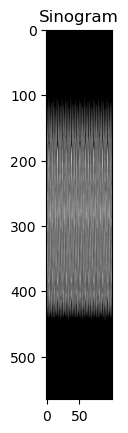

In [7]:
plot = plt.figure();
plot = plt.imshow(ex_sinogram.T, cmap='grey');
plt.title("Sinogram");
#plt.savefig('fig/example_astra_all.png');
plt.show(plot)

In [30]:
f_measured = ex_sinogram; # transpose from ASTRA format
u = ex_reconstructed.copy(); # initial guess of FBP of sinogram

iterations = 50;
learning_rate = 1e-6; # step size
lambda_tv = 0.15; # aggressiveness of TV (higher is more aggressive smoothing)

for i in range(iterations):
    # data fidelity step
    sino_id, Au = astra.create_sino(u, proj_id);
    error_sino = Au - f_measured; # should this be normalized?

    err_vol_id, gradient_image = astra.create_backprojection(error_sino, proj_id);

    u_updated = u - (learning_rate * gradient_image);

    # denoising
    u = denoise_tv_chambolle(u_updated, weight=lambda_tv);
    u = np.clip(u, 0, None); # enforce non-negativity

    # cleanup
    astra.data2d.delete(sino_id);
    astra.data2d.delete(err_vol_id);

    print(f"Iter {i}, error norm: {np.linalg.norm(error_sino):.2f}");

Iter 0, error norm: 136805.98
Iter 1, error norm: 132662.83
Iter 2, error norm: 128660.45
Iter 3, error norm: 124811.02
Iter 4, error norm: 121098.12
Iter 5, error norm: 117555.64
Iter 6, error norm: 114148.02
Iter 7, error norm: 110896.93
Iter 8, error norm: 107784.30
Iter 9, error norm: 104804.26
Iter 10, error norm: 101952.13
Iter 11, error norm: 99222.84
Iter 12, error norm: 96611.41
Iter 13, error norm: 94113.03
Iter 14, error norm: 91723.05
Iter 15, error norm: 89436.68
Iter 16, error norm: 87249.34
Iter 17, error norm: 85156.90
Iter 18, error norm: 83155.20
Iter 19, error norm: 81240.32
Iter 20, error norm: 79408.52
Iter 21, error norm: 77656.16
Iter 22, error norm: 75979.74
Iter 23, error norm: 74384.58
Iter 24, error norm: 72860.09
Iter 25, error norm: 71402.34
Iter 26, error norm: 70008.11
Iter 27, error norm: 68674.30
Iter 28, error norm: 67397.92
Iter 29, error norm: 66175.96
Iter 30, error norm: 65005.88
Iter 31, error norm: 63885.04
Iter 32, error norm: 62801.88
Iter 33, 

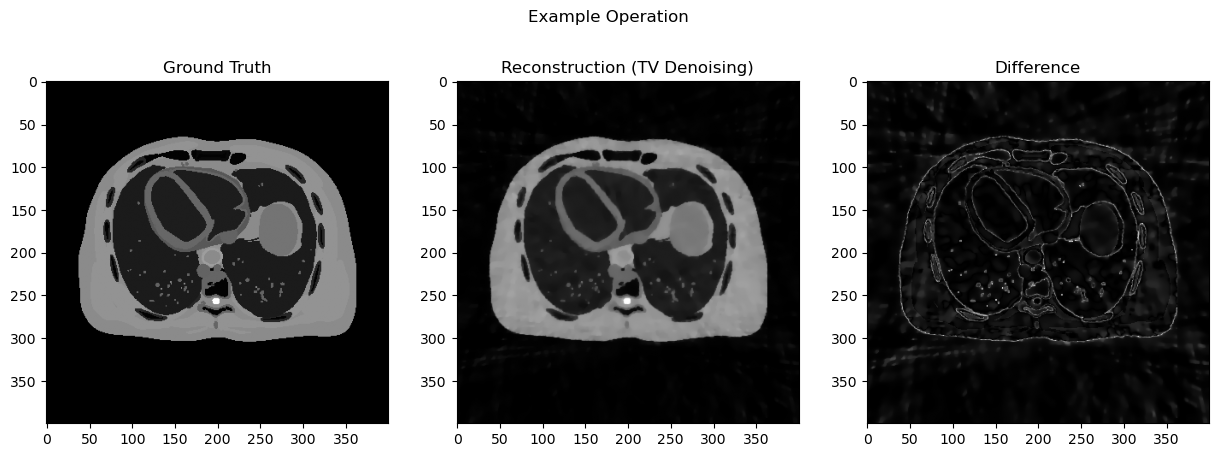

In [31]:
u_norm = u / np.max(u); # normalize
diff = np.abs(ex_gt_norm - u_norm);

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5));
fig.suptitle('Example Operation');

ax1.set_title('Ground Truth');
im1 = ax1.imshow(ex_gt, cmap='grey');

ax2.set_title('Reconstruction (TV Denoising)');
im2 = ax2.imshow(u_norm, cmap='grey');

ax3.set_title('Difference');
im3 = ax3.imshow(diff, cmap='grey');

plt.savefig('fig/Example.png');
plt.show();

# Example: Static Image, 100 Spokes (skimage)

Example of forward/backward projection using the Scikit Image library

In [ ]:
# Example
GOLDEN_ANGLE = 111.246;
ex_gt = data[0, 10, :, :];
ex_gt = np.rot90(ex_gt, k=-1, axes=(0,1));
ex_gt = ex_gt.astype(float)

angles = np.arange(100) * GOLDEN_ANGLE;
angles = np.mod(angles, 180.0);

# forward process
ex_sinogram = radon(ex_gt, theta=angles, circle=False);

# backward process
ex_reconstructed = iradon(ex_sinogram, theta=angles, filter_name='ramp', circle=False);

# clip negative values
ex_reconstructed = np.clip(ex_reconstructed, 0, None);

# normalize
ex_gt_norm = ex_gt / np.max(ex_gt);
ex_reconstructed_norm = ex_reconstructed / np.max(ex_reconstructed);

# calculate difference
diff = np.abs(ex_gt_norm - ex_reconstructed_norm);

print(f"Ground Truth Min: {np.min(ex_gt)}, Max: {np.max(ex_gt)}")
print(f"Recon Min: {np.min(ex_reconstructed)}, Max: {np.max(ex_reconstructed)}")
print(f"Diff Min: {np.min(diff)}, Max: {np.max(diff)}")

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5));
fig.suptitle('Example Operation');

ax1.set_title('Ground Truth');
im1 = ax1.imshow(ex_gt, cmap='grey');

ax2.set_title('Reconstruction (Backward Process)');
im2 = ax2.imshow(ex_reconstructed, cmap='grey');

ax3.set_title('Difference');
im3 = ax3.imshow(diff, cmap='grey');

plt.savefig('fig/Example.png');
plt.show();